 # Setup

In [32]:
PASCODE_PATH = ".."

import sys
sys.path.append(PASCODE_PATH) # NOTE
import PASCode
PASCode.random_seed.set_seed(0)

import scanpy as sc
import numpy as np
import torch

DATA_PATH = '../data/' # NOTE

 # Step 1: prepare data

 ## load data

In [33]:
file_path = DATA_PATH + 'synth_demo.h5ad'
adata = sc.read_h5ad(file_path)

 ## specify relevant columns and look at data

In [34]:
cond_col = 'syn_label' # condition column
pos_cond = 'cond1' # positive condition
neg_cond = 'cond2'  # negative condition
subid_col = 'subid' # donor id column

subinfo = PASCode.utils.subject_info(
    adata.obs, 
    subid_col=subid_col, 
    columns=[cond_col])
print(subinfo[cond_col].value_counts())

syn_label
cond2    13
cond1     6
Name: count, dtype: int64


 ## preprocess data

In [35]:
sc.pp.scale(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

 ## visualize

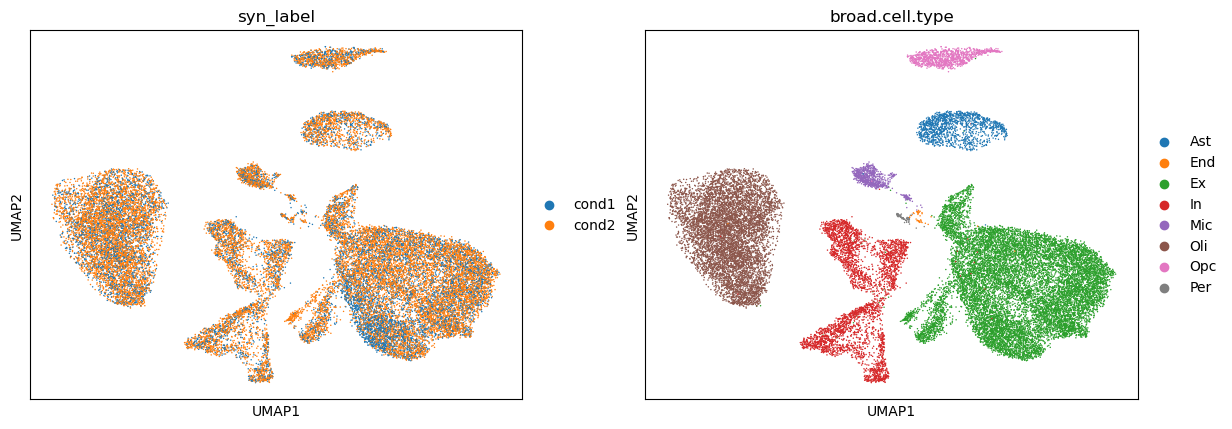

In [36]:
sc.pl.umap(adata, color=[cond_col, 'broad.cell.type'])

 ## subsample balanced donors

In [37]:
sub_sel = subinfo[(subinfo[cond_col] == pos_cond)].sample(n=6).index.values # NOTE
sub_sel = np.concatenate([sub_sel, subinfo[(subinfo[cond_col] == neg_cond)].sample(n=6).index.values])
adata_pac = adata[adata.obs[subid_col].isin(sub_sel).values]
subinfo = PASCode.utils.subject_info(
    adata_pac.obs, 
    subid_col=subid_col, 
    columns=[cond_col])
print(subinfo[cond_col].value_counts())

syn_label
cond2    6
cond1    6
Name: count, dtype: int64


 ## preprocess and visualize subsampled data

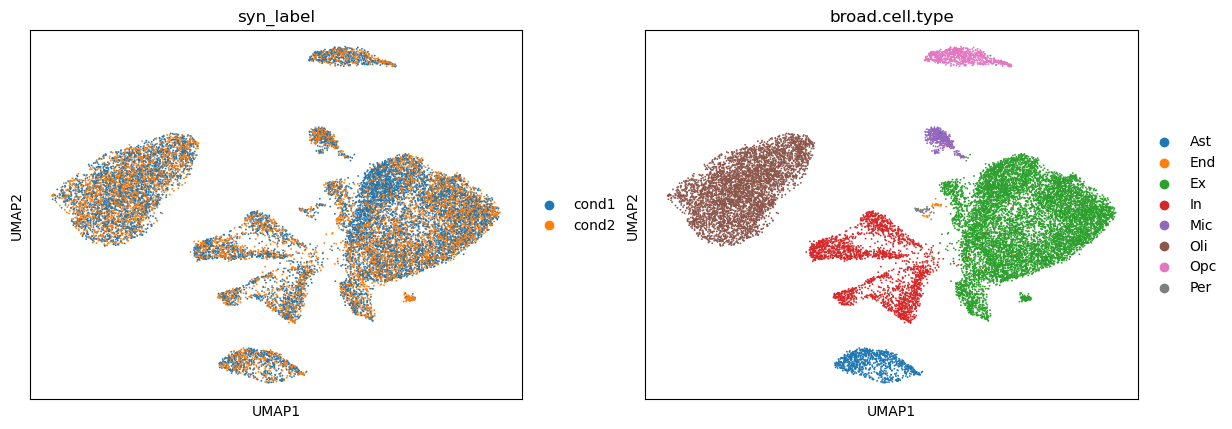

In [38]:
sc.pp.pca(adata_pac)
sc.pp.neighbors(adata_pac)
sc.tl.umap(adata_pac)

sc.pl.umap(adata_pac, color=[cond_col, 'broad.cell.type'])

 # Step 2: run DA tools and RRA to get cell aggregate dlabels

syn_label
cond2    6
cond1    6
Name: count, dtype: int64

----------------------------- Milo started ... -----------------------------
Making neighborhoods...
Counting neighborhoods...
Running differential abundance testing...
----------------------------- Milo Time cost (s):  2.92  -----------------------------


 ----------------------------- MELD started ... -----------------------------
Building graph on 17644 samples and 50 features.
Calculating graph and diffusion operator...
  Calculating KNN search...
  Calculated KNN search in 15.95 seconds.
  Calculating affinities...
  Calculated affinities in 0.75 seconds.
Calculated graph and diffusion operator in 17.43 seconds.
----------------------------- MELD Time cost (s):  18.09  -----------------------------


----------------------------- DA-seq started ... -----------------------------
Calculating DA score vector.
Running GLM.
Test on random labels.
Setting thresholds based on permutation
----------------------------- DA-seq Time

<Axes: xlabel='rra_pac', ylabel='Count'>

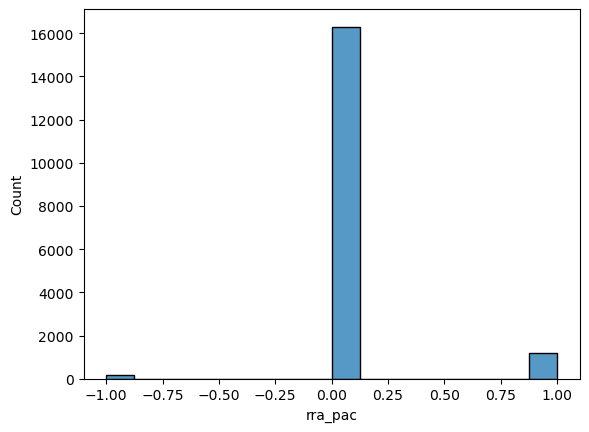

In [43]:
subinfo = PASCode.utils.subject_info(adata_pac.obs, subid_col, columns=[cond_col])
print(subinfo[cond_col].value_counts())

PASCode.pac.run_milo(adata_pac, subid_col=subid_col, cond_col=cond_col, pos_cond=pos_cond, neg_cond=neg_cond)
PASCode.pac.run_meld(adata_pac, cond_col=cond_col, pos_cond=pos_cond, neg_cond=neg_cond, beta=10, knn=15)
PASCode.pac.run_daseq(adata_pac, subid_col=subid_col, cond_col=cond_col, pos_cond=pos_cond, neg_cond=neg_cond)
PASCode.rankaggr.rra(adata_pac, score_cols=['milo','meld', 'daseq'])

adata_pac.obs['rra_pac'] = PASCode.pac.assign_pac(
    scores=adata_pac.obs['rra_milo_meld_daseq'].values, mode='cutoff', cutoff=0.5)

print(adata_pac.obs['rra_pac'].value_counts())
import seaborn as sns
sns.histplot(adata_pac.obs['rra_pac'])

 # Step 3: train GAT model

 ## prepare PACs

In [44]:
adata.obs['rra_pac'] = np.nan
adata.obs.loc[adata_pac.obs.index, 'rra_pac'] = adata_pac.obs['rra_pac'].values
print(adata.obs['rra_pac'].value_counts())
adata.obs['rra_pac_mask'] = adata.obs.index.isin(adata_pac.obs.index)

rra_pac
 0.0    16304
 1.0     1177
-1.0      163
Name: count, dtype: int64


 ## prepare donors for validation

In [ ]:
subinfo = PASCode.utils.subject_info(adata_pac.obs, 
                                     subid_col=subid_col, 
                                     columns=[cond_col])
sel1 = subinfo[(subinfo[cond_col] == neg_cond)] \
        .sample(n=1).index.values # NOTE
sel2 = subinfo[(subinfo[cond_col] == neg_cond)] \
        .sample(n=1).index.values # NOTE
sub_sel = np.concatenate([sel1, sel2])
adata_pac.obs['val_mask'] = adata_pac.obs[subid_col].isin(sub_sel).values
adata_pac.obs['train_mask'] = ~adata_pac.obs['val_mask']
adata.obs['train_mask'] = adata.obs.index \
    .isin(adata_pac.obs.index[adata_pac.obs['train_mask']])
adata.obs['val_mask'] = adata.obs.index \
    .isin(adata_pac.obs.index[adata_pac.obs['val_mask']])

 ## prepare data loader and batches

In [52]:
data = PASCode.model.Data().adata2gdata(
    adata, 
    y=adata.obs['rra_pac'].values + 1, 
    trn_mask=adata.obs['train_mask'].values, 
    val_mask=adata.obs['val_mask'].values)
data_loader = PASCode.model.Data().gdata2batch(
    data, 
    batch_size=64, # NOTE
    num_parts=256, # NOTE
    shuffle=True)

Constructing batches...


Computing METIS partitioning...


Batch construction done.


Done!


 ## train model

Training...
Epoch: 1/100 - lr: 1.000e-03 - train_loss: 0.646 - val_loss: 0.173 
Epoch: 2/100 - lr: 1.000e-03 - train_loss: 0.234 - val_loss: 0.145 
Epoch: 3/100 - lr: 1.000e-03 - train_loss: 0.145 - val_loss: 0.133 
Epoch: 4/100 - lr: 1.000e-03 - train_loss: 0.121 - val_loss: 0.139 
Epoch: 5/100 - lr: 1.000e-03 - train_loss: 0.113 - val_loss: 0.124 
Epoch: 6/100 - lr: 1.000e-03 - train_loss: 0.117 - val_loss: 0.110 
Epoch: 7/100 - lr: 1.000e-03 - train_loss: 0.104 - val_loss: 0.112 
Epoch: 8/100 - lr: 1.000e-03 - train_loss: 0.104 - val_loss: 0.096 
Epoch: 9/100 - lr: 1.000e-03 - train_loss: 0.094 - val_loss: 0.097 
Epoch: 10/100 - lr: 1.000e-03 - train_loss: 0.093 - val_loss: 0.092 
Epoch: 11/100 - lr: 1.000e-03 - train_loss: 0.089 - val_loss: 0.088 
Epoch: 12/100 - lr: 1.000e-03 - train_loss: 0.083 - val_loss: 0.087 
Epoch: 13/100 - lr: 1.000e-03 - train_loss: 0.083 - val_loss: 0.080 
Epoch: 14/100 - lr: 1.000e-03 - train_loss: 0.079 - val_loss: 0.077 
Epoch: 15/100 - lr: 1.000e-03 -

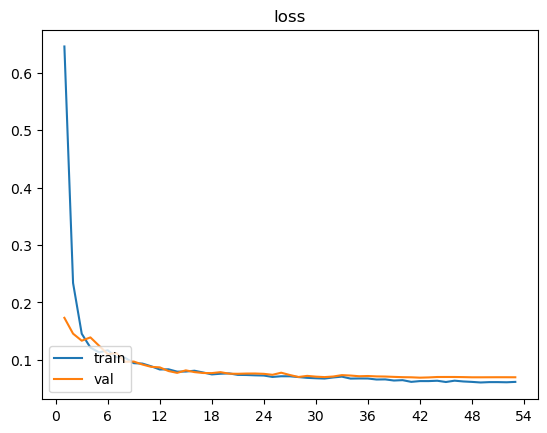

In [53]:
model = PASCode.model.GAT(
    in_channels=adata.X.shape[1], out_channels=64, num_class=3, heads=4)

best_model = PASCode.model.Trainer(model=model, device='cuda').train(
    trn_data_loader=data_loader, data_val=data, val_data_loader=None,
    max_epoch=100, lr=1e-3, lr_decay=[2, 0.5], early_stopping=10, weight_decay=1e-3, # NOTE
    class_weight=[1, 1, 1])
model = best_model

torch.save(model.state_dict(), './trained_model.pt')

 # Step 4: using the trained model for PAC score predictions

In [54]:
model.load_state_dict(torch.load('./trained_model.pt'))

adata.obs['pac_score'] = model.predict(PASCode.Data().adata2gdata(adata))